<center><b>State Classification Based On Energy </b><center>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [33]:
df = pd.read_csv("WiDS Dataton.csv")
df.head()

,Year_Factor,State_Factor,building_class,facility_type,floor_area,year_built,energy_star_rating,ELEVATION,january_min_temp,january_avg_temp,...,december_min_temp,days_below_10F,days_below_0F,days_above_80F,direction_max_wind_speed,direction_peak_wind_speed,max_wind_speed,days_with_fog,site_eui,id
0,1,State_1,Commercial,Grocery_store_or_food_market,61242.0,1942.0,11.0,2.4,36,50.5,...,36,0,0,14,1.0,1.0,1.0,NaN,248.682615,0
1,1,State_1,Commercial,Warehouse_Distribution_or_Shipping_center,274000.0,1955.0,45.0,1.8,36,50.5,...,36,0,0,14,1.0,NaN,1.0,12.0,26.500150,1
2,1,State_1,Commercial,Retail_Enclosed_mall,280025.0,1951.0,97.0,1.8,36,50.5,...,36,0,0,14,1.0,NaN,1.0,12.0,24.693619,2
3,1,State_1,Commercial,Education_Other_classroom,55325.0,1980.0,46.0,1.8,36,50.5,...,36,0,0,14,1.0,NaN,1.0,12.0,48.406926,3
4,1,State_1,Commercial,Warehouse_Nonrefrigerated,66000.0,1985.0,100.0,2.4,36,50.5,...,36,0,0,14,1.0,1.0,1.0,NaN,3.899395,4


| Feature                       | Type                        | الوصف                                                             | التأثير المتوقع على **State_Factor**                                              |
| ----------------------------- | --------------------------- | ----------------------------------------------------------------- | --------------------------------------------------------------------------------- |
| **Year_Factor**               | Numerical أو Categorical    | السنة التي تم فيها تسجيل البيانات.                                | قد تساعد في التمييز بين الولايات إذا كانت البيانات مجمعة على سنوات مختلفة.        |
| **building_class**            | Categorical                 | التصنيف العام للمبنى (Commercial, Residential...).                | بعض أنواع المباني تنتشر أكثر في ولايات معينة.                                     |
| **facility_type**             | Categorical                 | الاستخدام الفعلي للمبنى (School, Office, Hospital...).            | قد يكون له علاقة بالولاية.                                                        |
| **floor_area**                | Numerical                   | مساحة المبنى.                                                     | قد تختلف متوسطات المساحات بين الولايات.                                           |
| **year_built**                | Numerical                   | سنة إنشاء المبنى.                                                 | بعض الولايات تحتوي على مبانٍ أحدث أو أقدم.                                        |
| **energy_star_rating**        | Numerical                   | تقييم كفاءة الطاقة (1–100).                                       | قد تختلف كفاءة المباني بين الولايات بسبب القوانين أو المناخ.                      |
| **ELEVATION**                 | Numerical                   | ارتفاع المبنى عن سطح البحر.                                       | من أكثر الـ Features التي قد تساعد في تحديد الولاية، لأن لكل ولاية تضاريس مختلفة. |
| **january_min_temp**          | Numerical                   | أقل درجة حرارة في يناير.                                          | مهم جدًا، لأن كل ولاية لها مناخ مختلف.                                            |
| **january_avg_temp**          | Numerical                   | متوسط حرارة يناير.                                                | يساعد في التمييز بين الولايات.                                                    |
| **... (باقي درجات الحرارة)**  | Numerical                   | درجات الحرارة لكل الشهور.                                         | غالبًا من أقوى الـ Features لأن المناخ يختلف من ولاية لأخرى.                      |
| **december_min_temp**         | Numerical                   | أقل درجة حرارة في ديسمبر.                                         | يساعد في تصنيف الولاية.                                                           |
| **days_below_10F**            | Numerical                   | عدد الأيام أقل من 10°F.                                           | يميز الولايات الباردة.                                                            |
| **days_below_0F**             | Numerical                   | عدد الأيام أقل من 0°F.                                            | مؤشر قوي للولايات شديدة البرودة.                                                  |
| **days_above_80F**            | Numerical                   | عدد الأيام أعلى من 80°F.                                          | يميز الولايات الحارة.                                                             |
| **direction_max_wind_speed**  | Numerical                   | اتجاه الرياح عند أعلى سرعة.                                       | قد يحمل معلومات مناخية عن الولاية.                                                |
| **direction_peak_wind_speed** | Numerical                   | اتجاه الرياح عند أقصى هبة.                                        | تأثيره غالبًا أقل.                                                                |
| **max_wind_speed**            | Numerical                   | أقصى سرعة رياح.                                                   | قد يساعد في التمييز بين المناطق الساحلية والداخلية.                               |
| **days_with_fog**             | Numerical                   | عدد أيام الضباب.                                                  | يميز بعض الولايات ذات الضباب المرتفع.                                             |
| **site_eui**                  | Numerical                   | مؤشر استهلاك الطاقة للمبنى.                                       | قد يختلف متوسطه من ولاية لأخرى حسب المناخ.                                        |
| **id**                        | Identifier                  | رقم تعريفي للمبنى.                                                | ❌ يُحذف قبل التدريب لأنه لا يحمل أي معلومة مفيدة.                                 |
| **State_Factor**              | **Target (Classification)** | **الولاية التي يقع فيها المبنى، وهي الفئة التي نريد التنبؤ بها.** | **المتغير الهدف (Label).**                                                        |


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31107 entries, 0 to 31106
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year_Factor                31107 non-null  int64  
 1   State_Factor               31107 non-null  object 
 2   building_class             31107 non-null  object 
 3   facility_type              31107 non-null  object 
 4   floor_area                 31107 non-null  float64
 5   year_built                 29614 non-null  float64
 6   energy_star_rating         14502 non-null  float64
 7   ELEVATION                  31107 non-null  float64
 8   january_min_temp           31107 non-null  int64  
 9   january_avg_temp           31107 non-null  float64
 10  january_max_temp           31107 non-null  int64  
 11  february_min_temp          31107 non-null  int64  
 12  february_avg_temp          31107 non-null  float64
 13  february_max_temp          31107 non-null  int

In [35]:
df.isnull().sum().sort_values(ascending=False)

direction_peak_wind_speed    19951
direction_max_wind_speed     19915
max_wind_speed               19915
days_with_fog                18486
energy_star_rating           16605
year_built                    1493
Year_Factor                      0
State_Factor                     0
building_class                   0
january_min_temp                 0
ELEVATION                        0
facility_type                    0
floor_area                       0
january_avg_temp                 0
january_max_temp                 0
february_min_temp                0
february_avg_temp                0
april_min_temp                   0
april_avg_temp                   0
april_max_temp                   0
may_min_temp                     0
february_max_temp                0
march_min_temp                   0
march_avg_temp                   0
march_max_temp                   0
june_avg_temp                    0
june_min_temp                    0
may_max_temp                     0
may_avg_temp        

In [36]:
df.nunique().sort_values(ascending=False)

id                           31107
site_eui                     29492
floor_area                   13567
ELEVATION                      165
year_built                     163
february_avg_temp              128
january_avg_temp               126
may_avg_temp                   126
march_avg_temp                 126
april_avg_temp                 125
june_avg_temp                  122
july_avg_temp                  122
energy_star_rating             100
days_above_80F                  90
facility_type                   58
january_min_temp                47
march_min_temp                  44
january_max_temp                44
february_min_temp               43
december_min_temp               41
february_max_temp               40
july_max_temp                   39
june_max_temp                   37
march_max_temp                  37
may_min_temp                    34
june_min_temp                   34
november_max_temp               33
may_max_temp                    32
april_max_temp      

In [37]:
df.describe()

,Year_Factor,floor_area,year_built,energy_star_rating,ELEVATION,january_min_temp,january_avg_temp,january_max_temp,february_min_temp,february_avg_temp,...,december_min_temp,days_below_10F,days_below_0F,days_above_80F,direction_max_wind_speed,direction_peak_wind_speed,max_wind_speed,days_with_fog,site_eui,id
count,31107.000000,3.110700e+04,29614.000000,14502.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,...,31107.000000,31107.000000,31107.000000,31107.000000,11192.000000,11156.000000,11192.000000,12621.000000,31107.000000,31107.000000
mean,3.443952,1.871731e+05,1951.965050,63.296580,54.695204,11.893625,35.576139,59.881184,16.640210,37.392627,...,21.055743,4.724403,1.481853,81.232327,27.514743,28.039799,2.213644,94.676095,82.807868,16282.458578
std,1.546936,2.790911e+05,41.628088,27.530835,80.185588,11.046873,8.346048,7.426185,11.968229,9.535982,...,11.140498,9.311605,4.222058,25.837622,87.805953,90.044984,4.079183,61.294237,60.621497,8984.450511
min,1.000000,9.430000e+02,0.000000,1.000000,-6.400000,-19.000000,10.806452,42.000000,-13.000000,13.250000,...,-16.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,12.000000,1.003281,0.000000
25%,2.000000,6.474700e+04,1926.000000,44.000000,11.900000,8.000000,29.966667,59.000000,13.000000,33.910714,...,19.000000,0.000000,0.000000,72.000000,1.000000,1.000000,1.000000,73.000000,54.859960,8508.500000
50%,3.000000,1.003200e+05,1952.000000,70.000000,25.600000,11.000000,35.080645,61.000000,17.000000,35.907407,...,22.000000,0.000000,0.000000,75.000000,1.000000,1.000000,1.000000,93.000000,73.857620,16285.000000
75%,5.000000,1.966765e+05,1979.000000,86.000000,45.700000,13.000000,37.322581,62.000000,20.000000,40.879310,...,28.000000,1.000000,0.000000,93.000000,1.000000,1.000000,1.000000,99.000000,95.503881,24061.500000
max,6.000000,6.385382e+06,2015.000000,100.000000,1924.500000,49.000000,64.758065,91.000000,48.000000,65.107143,...,44.000000,59.000000,31.000000,260.000000,360.000000,360.000000,21.500000,311.000000,993.428259,31838.000000


In [38]:
df["year_built"].replace(0, df["year_built"].mode()[0], inplace=True)

In [39]:
df.describe()

,Year_Factor,floor_area,year_built,energy_star_rating,ELEVATION,january_min_temp,january_avg_temp,january_max_temp,february_min_temp,february_avg_temp,...,december_min_temp,days_below_10F,days_below_0F,days_above_80F,direction_max_wind_speed,direction_peak_wind_speed,max_wind_speed,days_with_fog,site_eui,id
count,31107.000000,3.110700e+04,29614.000000,14502.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,...,31107.000000,31107.000000,31107.000000,31107.000000,11192.000000,11156.000000,11192.000000,12621.000000,31107.000000,31107.000000
mean,3.443952,1.871731e+05,1952.290741,63.296580,54.695204,11.893625,35.576139,59.881184,16.640210,37.392627,...,21.055743,4.724403,1.481853,81.232327,27.514743,28.039799,2.213644,94.676095,82.807868,16282.458578
std,1.546936,2.790911e+05,33.008391,27.530835,80.185588,11.046873,8.346048,7.426185,11.968229,9.535982,...,11.140498,9.311605,4.222058,25.837622,87.805953,90.044984,4.079183,61.294237,60.621497,8984.450511
min,1.000000,9.430000e+02,1600.000000,1.000000,-6.400000,-19.000000,10.806452,42.000000,-13.000000,13.250000,...,-16.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,12.000000,1.003281,0.000000
25%,2.000000,6.474700e+04,1926.000000,44.000000,11.900000,8.000000,29.966667,59.000000,13.000000,33.910714,...,19.000000,0.000000,0.000000,72.000000,1.000000,1.000000,1.000000,73.000000,54.859960,8508.500000
50%,3.000000,1.003200e+05,1952.000000,70.000000,25.600000,11.000000,35.080645,61.000000,17.000000,35.907407,...,22.000000,0.000000,0.000000,75.000000,1.000000,1.000000,1.000000,93.000000,73.857620,16285.000000
75%,5.000000,1.966765e+05,1979.000000,86.000000,45.700000,13.000000,37.322581,62.000000,20.000000,40.879310,...,28.000000,1.000000,0.000000,93.000000,1.000000,1.000000,1.000000,99.000000,95.503881,24061.500000
max,6.000000,6.385382e+06,2015.000000,100.000000,1924.500000,49.000000,64.758065,91.000000,48.000000,65.107143,...,44.000000,59.000000,31.000000,260.000000,360.000000,360.000000,21.500000,311.000000,993.428259,31838.000000


In [40]:
df.columns

Index(['Year_Factor', 'State_Factor', 'building_class', 'facility_type',
       'floor_area', 'year_built', 'energy_star_rating', 'ELEVATION',
       'january_min_temp', 'january_avg_temp', 'january_max_temp',
       'february_min_temp', 'february_avg_temp', 'february_max_temp',
       'march_min_temp', 'march_avg_temp', 'march_max_temp', 'april_min_temp',
       'april_avg_temp', 'april_max_temp', 'may_min_temp', 'may_avg_temp',
       'may_max_temp', 'june_min_temp', 'june_avg_temp', 'june_max_temp',
       'july_min_temp', 'july_avg_temp', 'july_max_temp', 'august_min_temp',
       'november_max_temp', 'december_min_temp', 'days_below_10F',
       'days_below_0F', 'days_above_80F', 'direction_max_wind_speed',
       'direction_peak_wind_speed', 'max_wind_speed', 'days_with_fog',
       'site_eui', 'id'],
      dtype='object')

In [41]:
df.drop(columns=["id"], inplace=True)

In [42]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
boolean_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)
print("Boolean Columns:", boolean_cols)

Numerical Columns: ['Year_Factor', 'floor_area', 'year_built', 'energy_star_rating', 'ELEVATION', 'january_min_temp', 'january_avg_temp', 'january_max_temp', 'february_min_temp', 'february_avg_temp', 'february_max_temp', 'march_min_temp', 'march_avg_temp', 'march_max_temp', 'april_min_temp', 'april_avg_temp', 'april_max_temp', 'may_min_temp', 'may_avg_temp', 'may_max_temp', 'june_min_temp', 'june_avg_temp', 'june_max_temp', 'july_min_temp', 'july_avg_temp', 'july_max_temp', 'august_min_temp', 'november_max_temp', 'december_min_temp', 'days_below_10F', 'days_below_0F', 'days_above_80F', 'direction_max_wind_speed', 'direction_peak_wind_speed', 'max_wind_speed', 'days_with_fog', 'site_eui']
Categorical Columns: ['State_Factor', 'building_class', 'facility_type']
Boolean Columns: []


In [43]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

In [44]:
lst = ["max_wind_speed","energy_star_rating","year_built"]
for i in lst:
    df[[i]] = imputer.fit_transform(df[[i]])

In [45]:
df["days_with_fog"] = df["days_with_fog"].fillna(0) 

In [46]:
df.drop(["direction_peak_wind_speed","direction_max_wind_speed","facility_type","energy_star_rating"],axis=1,inplace=True)

In [47]:
df.isnull().sum().sum()

np.int64(0)

In [48]:
df.shape

(31107, 36)

In [49]:
df.reset_index(drop=True,inplace=True)

In [50]:
df.describe()

,Year_Factor,floor_area,year_built,ELEVATION,january_min_temp,january_avg_temp,january_max_temp,february_min_temp,february_avg_temp,february_max_temp,...,july_max_temp,august_min_temp,november_max_temp,december_min_temp,days_below_10F,days_below_0F,days_above_80F,max_wind_speed,days_with_fog,site_eui
count,31107.000000,3.110700e+04,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,...,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000,31107.000000
mean,3.443952,1.871731e+05,1952.276787,54.695204,11.893625,35.576139,59.881184,16.640210,37.392627,62.297039,...,97.460700,57.716334,71.663838,21.055743,4.724403,1.481853,81.232327,1.436657,38.412801,82.807868
std,1.546936,2.790911e+05,32.206556,80.185588,11.046873,8.346048,7.426185,11.968229,9.535982,7.441591,...,4.699108,3.773497,4.956344,11.140498,9.311605,4.222058,25.837622,2.515107,60.708683,60.621497
min,1.000000,9.430000e+02,1600.000000,-6.400000,-19.000000,10.806452,42.000000,-13.000000,13.250000,41.000000,...,65.000000,31.000000,60.000000,-16.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.003281
25%,2.000000,6.474700e+04,1927.000000,11.900000,8.000000,29.966667,59.000000,13.000000,33.910714,55.000000,...,96.000000,55.000000,66.000000,19.000000,0.000000,0.000000,72.000000,1.000000,0.000000,54.859960
50%,3.000000,1.003200e+05,1952.000000,25.600000,11.000000,35.080645,61.000000,17.000000,35.907407,62.000000,...,98.000000,59.000000,70.000000,22.000000,0.000000,0.000000,75.000000,1.000000,0.000000,73.857620
75%,5.000000,1.966765e+05,1976.000000,45.700000,13.000000,37.322581,62.000000,20.000000,40.879310,67.000000,...,100.000000,61.000000,76.000000,28.000000,1.000000,0.000000,93.000000,1.000000,79.000000,95.503881
max,6.000000,6.385382e+06,2015.000000,1924.500000,49.000000,64.758065,91.000000,48.000000,65.107143,89.000000,...,117.000000,72.000000,94.000000,44.000000,59.000000,31.000000,260.000000,21.500000,311.000000,993.428259


In [51]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["State_Factor"] = le.fit_transform(df["State_Factor"])
df['building_class'] = le.fit_transform(df['building_class'])

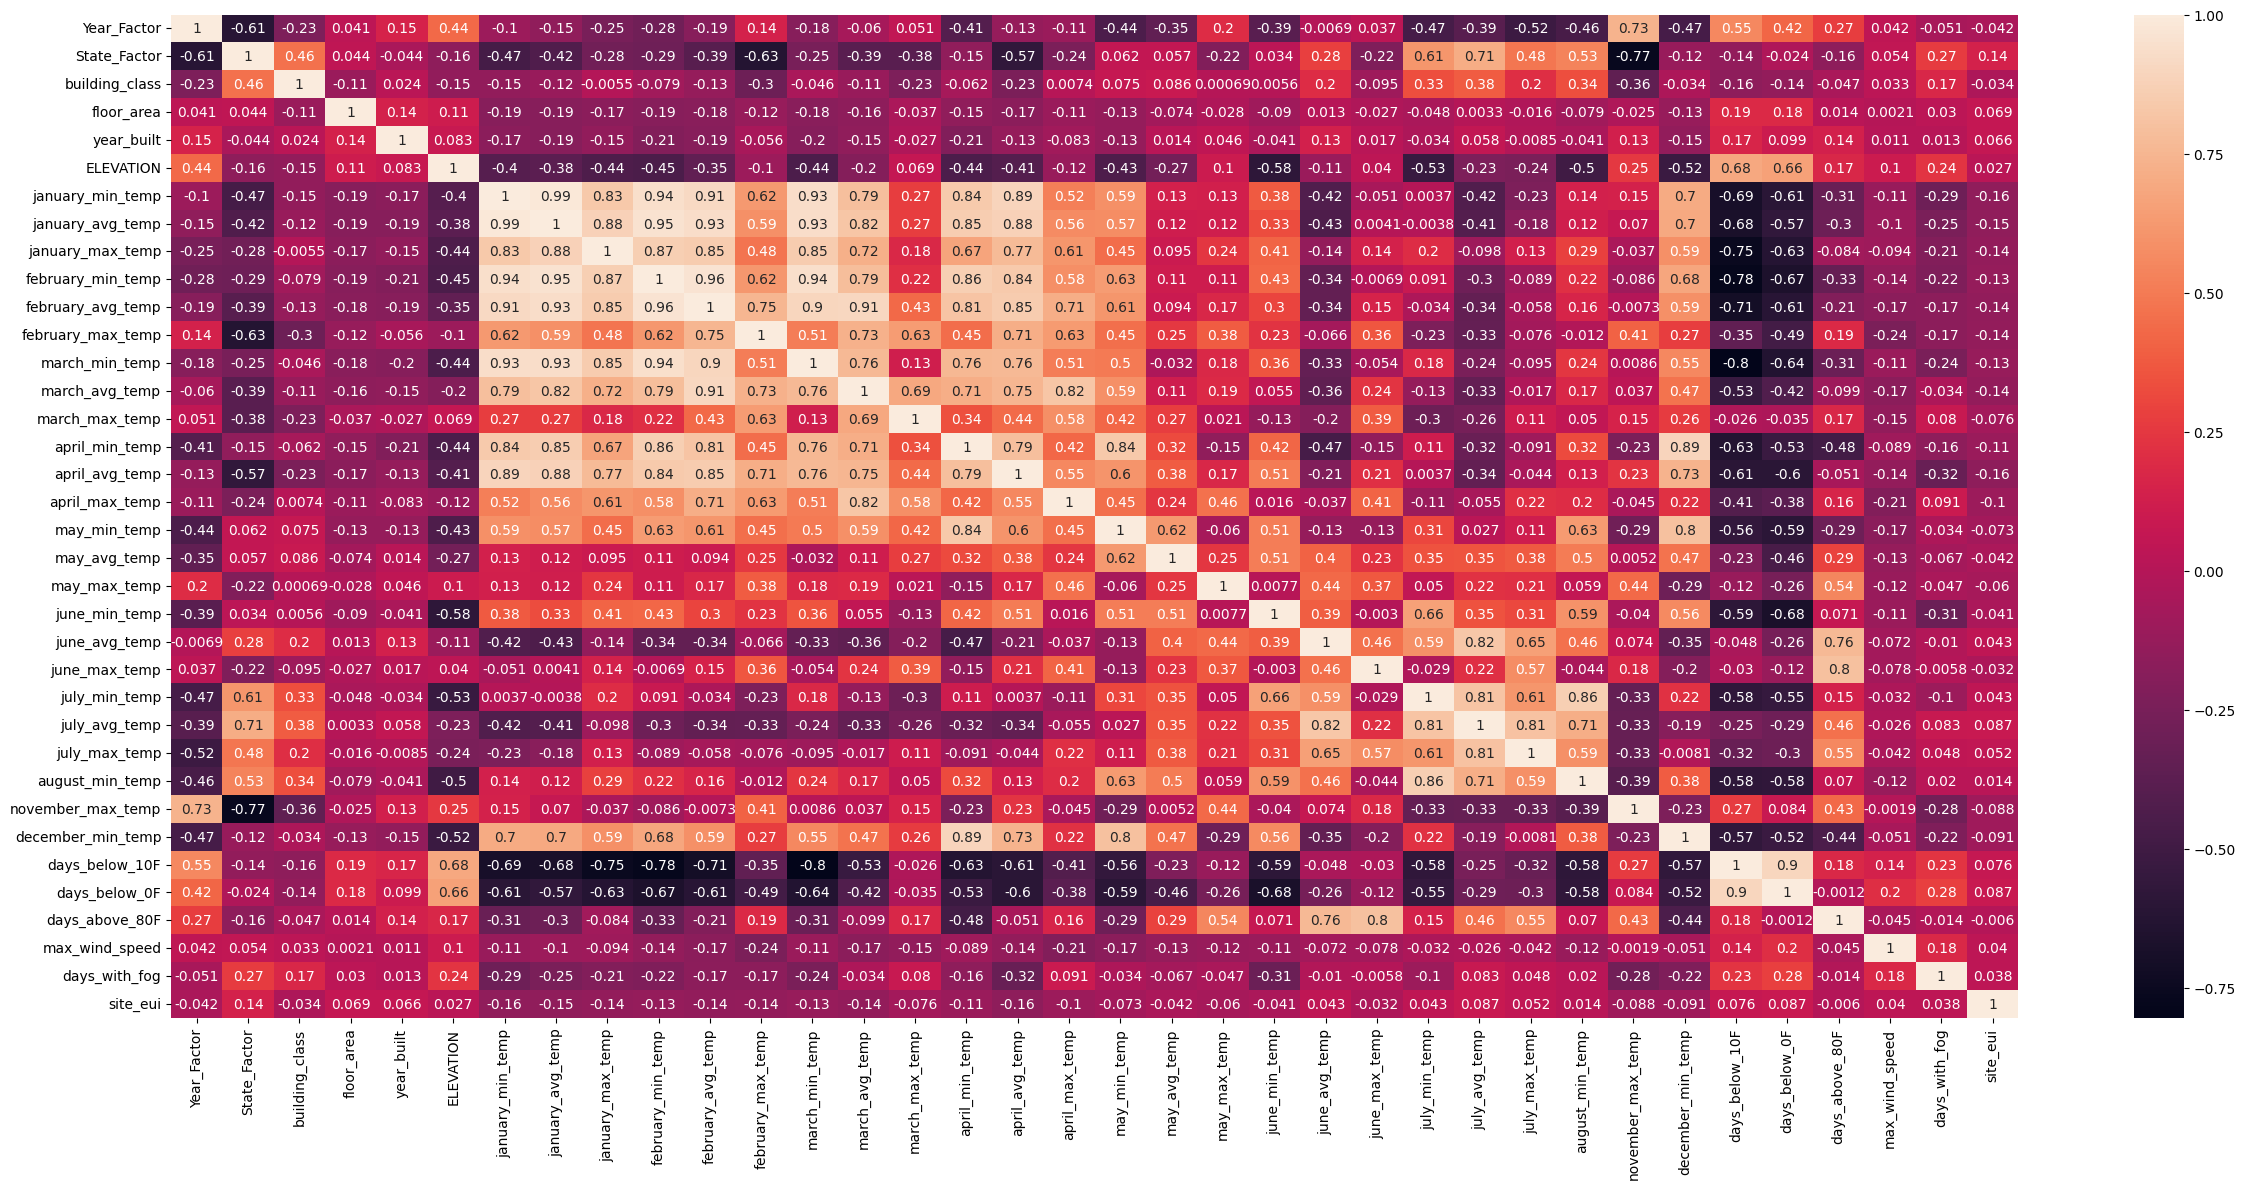

In [52]:
plt.figure(figsize=(25,12))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.tight_layout()
plt.show()

In [53]:
from sklearn.model_selection import train_test_split
X = df.drop("State_Factor",axis=1)
y = df["State_Factor"]

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
from sklearn.linear_model import LogisticRegression
LoR = LogisticRegression()

LoR.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [56]:
y_pred = LoR.predict(X_test_scaled)

In [57]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:\n", accuracy_score(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       977
           1       1.00      1.00      1.00       974
           2       1.00      1.00      1.00       860
           3       1.00      1.00      1.00      3411

    accuracy                           1.00      6222
   macro avg       1.00      1.00      1.00      6222
weighted avg       1.00      1.00      1.00      6222

Accuracy Score:
 1.0


<Axes: >

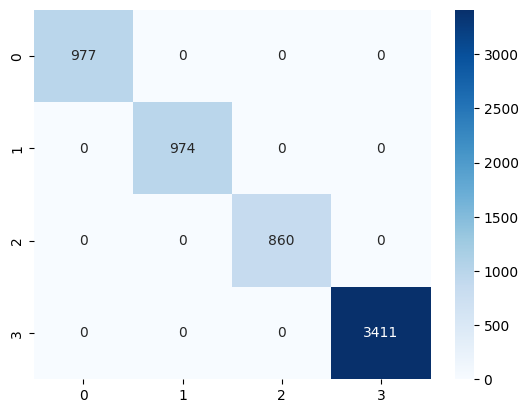

In [58]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')

<center><b>Thank You</b><center>